In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/GCD/paired_dataset.h5"  # Adjust based on where you uploaded it

Total samples: 28150
Training samples: 22520, Validation samples: 5630

Training model on device: cuda...
Epoch [1/100] | LR: 1.000000e-03 | Train Loss: 0.301661 | Val Loss: 0.178916
Epoch [5/100] | LR: 1.000000e-03 | Train Loss: 0.150705 | Val Loss: 0.134253
Epoch [10/100] | LR: 1.000000e-03 | Train Loss: 0.110422 | Val Loss: 0.108595
Epoch [15/100] | LR: 1.000000e-03 | Train Loss: 0.086329 | Val Loss: 0.095120
Epoch [20/100] | LR: 1.000000e-03 | Train Loss: 0.073548 | Val Loss: 0.088408
Epoch [25/100] | LR: 1.000000e-03 | Train Loss: 0.063566 | Val Loss: 0.088070
Epoch [30/100] | LR: 1.000000e-03 | Train Loss: 0.052419 | Val Loss: 0.078643
Epoch [35/100] | LR: 1.000000e-03 | Train Loss: 0.046934 | Val Loss: 0.082130
Epoch [40/100] | LR: 1.000000e-03 | Train Loss: 0.043915 | Val Loss: 0.073240
Epoch [45/100] | LR: 1.000000e-03 | Train Loss: 0.037542 | Val Loss: 0.072316
Epoch [50/100] | LR: 1.000000e-03 | Train Loss: 0.035521 | Val Loss: 0.070340
Epoch [55/100] | LR: 1.000000e-03 | Tr

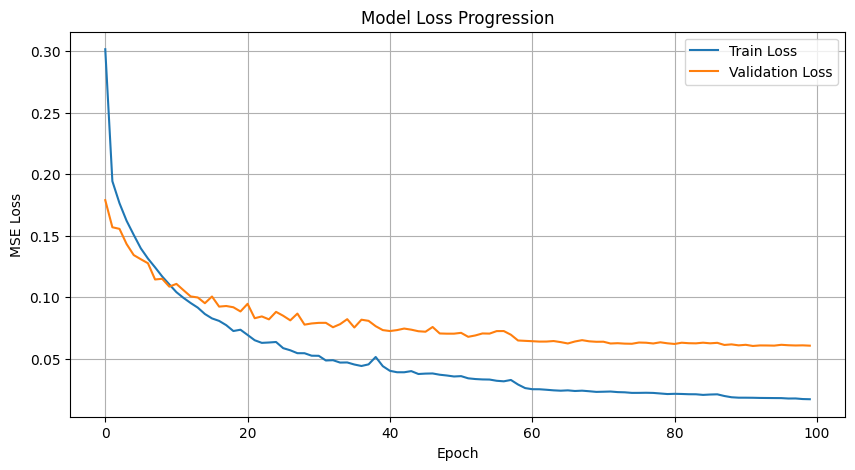

In [ ]:
# @title Training

"""
TouchPose-Inspired Capacitance-to-3D Hand Pose Estimator
Designed for Google Colab (with GPU acceleration)

Instructions for running in Google Colab:
1. Upload the generated 'paired_dataset.h5' file (found in C:\\GCD_Datas\\) to your Google Drive.
2. Open a new Google Colab notebook with GPU runtime enabled (Runtime -> Change runtime type -> T4 GPU).
3. Mount Google Drive by running in Colab:
   from google.colab import drive
   drive.mount('/content/drive')
4. Run this script. Adjust DATASET_PATH to point to your uploaded 'paired_dataset.h5' file in Drive, e.g.:
   DATASET_PATH = "/content/drive/MyDrive/paired_dataset.h5"
"""

import os
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VAL_RATIO = 0.20 # Ratio of runs reserved for validation

# --- PYTORCH DATASET LOADER ---
class CapacitanceHandPoseDataset(Dataset):
    def __init__(self, h5_path, run_indices=None):
        self.h5_path = h5_path

        # Load data into memory (RAM) to bypass high latency of Google Drive file reads
        with h5py.File(self.h5_path, 'r') as f:
            run_ids = f['run_ids'][:]

            if run_indices is not None:
                # Mask corresponding to specified run IDs
                self.indices = np.where(np.isin(run_ids, run_indices))[0]
            else:
                self.indices = np.arange(len(run_ids))

            # Pre-load only the sliced datasets into RAM
            self.capacitance = f['capacitance'][self.indices]
            self.joints = f['joints'][self.indices]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Return tensors directly from RAM
        return (torch.tensor(self.capacitance[idx], dtype=torch.float32),
                torch.tensor(self.joints[idx].flatten(), dtype=torch.float32))

# --- MODEL ARCHITECTURE ---
class CapacitanceHandPoseNet(nn.Module):
    def __init__(self):
        super(CapacitanceHandPoseNet, self).__init__()

        # Convolutional Backbone
        self.conv1 = nn.Conv2d(2, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()

        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # downsamples 14x8 to 7x4

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()

        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # downsamples 7x4 to 3x2 (pooling odd dimension drops edge pixel)

        # Fully Connected Classifier
        # Flattened shape: 128 channels * 3 * 2 = 768
        self.fc1 = nn.Linear(768, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.relu_fc1 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        self.fc2 = nn.Linear(256, 128)
        self.relu_fc2 = nn.ReLU()

        # Predict 63 joint values (21 joints * 3 coords)
        self.fc3 = nn.Linear(128, 63)

    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.pool2(x)

        x = x.view(x.size(0), -1) # Flatten

        x = self.dropout(self.relu_fc1(self.bn_fc1(self.fc1(x))))
        x = self.relu_fc2(self.fc2(x))
        x = self.fc3(x)

        return x

def main():
    if not os.path.exists(DATASET_PATH):
        print(f"Error: Dataset not found at {DATASET_PATH}.")
        print("Please check DATASET_PATH config or upload paired_dataset.h5 to Google Colab.")
        return

    # --- RANDOM SPLIT BY FRAMES ---
    full_dataset = CapacitanceHandPoseDataset(DATASET_PATH)
    total_samples = len(full_dataset)
    val_size = int(total_samples * VAL_RATIO)
    train_size = total_samples - val_size

    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Total samples: {total_samples}")
    print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

    # --- MODEL & TRAINING PARAMETERS ---
    model = CapacitanceHandPoseNet().to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')

    print(f"\nTraining model on device: {DEVICE}...")

    for epoch in range(EPOCHS):
        model.train()
        epoch_train_loss = 0.0
        for cap_img, gt_joints in train_loader:
            cap_img, gt_joints = cap_img.to(DEVICE), gt_joints.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(cap_img)
            loss = criterion(outputs, gt_joints)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * cap_img.size(0)

        epoch_train_loss /= len(train_dataset)
        train_losses.append(epoch_train_loss)

        # Validation Phase
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for cap_img, gt_joints in val_loader:
                cap_img, gt_joints = cap_img.to(DEVICE), gt_joints.to(DEVICE)
                outputs = model(cap_img)
                loss = criterion(outputs, gt_joints)
                epoch_val_loss += loss.item() * cap_img.size(0)

        epoch_val_loss /= len(val_dataset)
        val_losses.append(epoch_val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(epoch_val_loss)

        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] | LR: {current_lr:.6e} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

        # Save best model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), "best_model.pth")

    print(f"\nTraining completed! Best Validation Loss: {best_val_loss:.6f}")

    # --- EVALUATION AND RESULTS ---
    # Load best weights
    model.load_state_dict(torch.load("best_model.pth"))
    model.eval()

    # Calculate average joint error in normalized space unit
    total_joint_err = 0.0
    with torch.no_grad():
        for cap_img, gt_joints in val_loader:
            cap_img, gt_joints = cap_img.to(DEVICE), gt_joints.to(DEVICE)
            outputs = model(cap_img)

            # Reshape output to (Batch, 21, 3)
            pred = outputs.view(-1, 21, 3)
            gt = gt_joints.view(-1, 21, 3)

            # Distance error per joint
            dist = torch.sqrt(torch.sum((pred - gt)**2, dim=2)) # (Batch, 21)
            total_joint_err += torch.mean(dist).item() * cap_img.size(0)

    avg_joint_err = total_joint_err / len(val_dataset)
    print(f"Average joint error on Validation Set: {avg_joint_err:.4f} unit distances")

    # --- PLOT LOSSES ---
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title("Model Loss Progression")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig("loss_progression.png")
    print("Saved training loss progression plot to loss_progression.png")

if __name__ == '__main__':
    main()


Total samples: 28150
Training samples: 22520, Validation samples: 5630

Training upgraded model on device: cuda...
Epoch [  1/120] | LR: 1.000000e-03 | Train Loss: 0.123833 | Val Loss: 0.075400
Epoch [  5/120] | LR: 9.972609e-04 | Train Loss: 0.061946 | Val Loss: 0.056206
Epoch [ 10/120] | LR: 9.861850e-04 | Train Loss: 0.046720 | Val Loss: 0.048457
Epoch [ 15/120] | LR: 9.667902e-04 | Train Loss: 0.036413 | Val Loss: 0.040898
Epoch [ 20/120] | LR: 9.394086e-04 | Train Loss: 0.028641 | Val Loss: 0.034343
Epoch [ 25/120] | LR: 9.045085e-04 | Train Loss: 0.022956 | Val Loss: 0.031713
Epoch [ 30/120] | LR: 8.626872e-04 | Train Loss: 0.019127 | Val Loss: 0.028888
Epoch [ 35/120] | LR: 8.146602e-04 | Train Loss: 0.016169 | Val Loss: 0.027955
Epoch [ 40/120] | LR: 7.612493e-04 | Train Loss: 0.013754 | Val Loss: 0.026036
Epoch [ 45/120] | LR: 7.033683e-04 | Train Loss: 0.011976 | Val Loss: 0.024699
Epoch [ 50/120] | LR: 6.420077e-04 | Train Loss: 0.010842 | Val Loss: 0.024012
Epoch [ 55/120] 

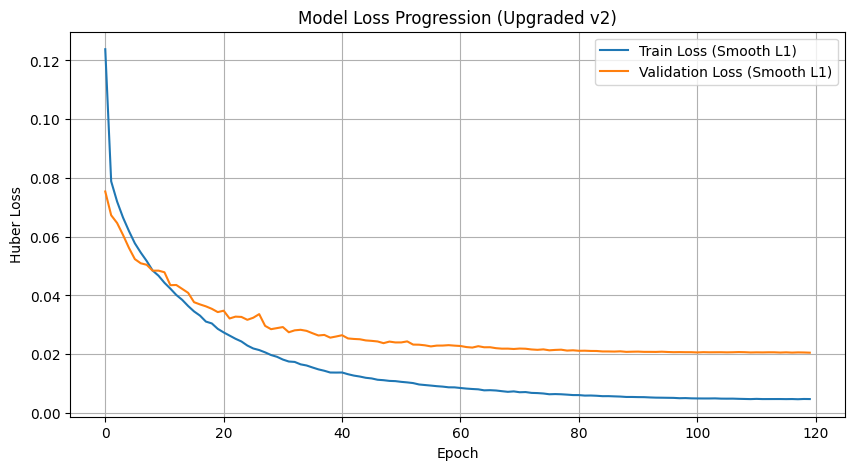

In [ ]:
# @title V2

"""
TouchPose-Inspired Capacitance-to-3D Hand Pose Estimator (Upgraded Version 2)
Designed for Google Colab (with GPU acceleration)

Features:
- CoordConv (Concatenates X/Y coordinate channels to the input)
- Residual CNN architecture (ResBlocks)
- Robust Huber Loss (Smooth L1) for coordinate regression
- Cosine Annealing Learning Rate Scheduler for smoother convergence
- RAM-cached dataset loading to avoid Google Drive read latency
"""

import os
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
BATCH_SIZE = 64
EPOCHS = 120
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VAL_RATIO = 0.20 # Ratio of frames reserved for validation

# --- PYTORCH DATASET LOADER (RAM CACHED) ---
class CapacitanceHandPoseDataset(Dataset):
    def __init__(self, h5_path, run_indices=None):
        self.h5_path = h5_path

        # Load data into memory (RAM) to bypass high latency of Google Drive file reads
        with h5py.File(self.h5_path, 'r') as f:
            run_ids = f['run_ids'][:]

            if run_indices is not None:
                # Mask corresponding to specified run IDs
                self.indices = np.where(np.isin(run_ids, run_indices))[0]
            else:
                self.indices = np.arange(len(run_ids))

            # Pre-load only the sliced datasets into RAM
            self.capacitance = f['capacitance'][self.indices]
            self.joints = f['joints'][self.indices]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Return tensors directly from RAM
        return (torch.tensor(self.capacitance[idx], dtype=torch.float32),
                torch.tensor(self.joints[idx].flatten(), dtype=torch.float32))

# --- COORDCONV2D MODULE ---
class CoordConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CoordConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels + 2, out_channels, **kwargs)

    def forward(self, x):
        batch_size, _, h, w = x.size()

        # Generate X and Y normalized coordinate grids
        xx = torch.arange(w, device=x.device, dtype=x.dtype).view(1, 1, 1, w).expand(batch_size, 1, h, w)
        yy = torch.arange(h, device=x.device, dtype=x.dtype).view(1, 1, h, 1).expand(batch_size, 1, h, w)

        # Normalize to [-1, 1]
        xx = xx / (w - 1) * 2 - 1
        yy = yy / (h - 1) * 2 - 1

        # Concatenate grids to the input channels
        x_coords = torch.cat([x, xx, yy], dim=1)
        return self.conv(x_coords)

# --- RESIDUAL CNN BLOCK ---
class ResBlock(nn.Module):
    def __init__(self, channels):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return self.relu(out)

# --- UPGRADED NETWORK ARCHITECTURE ---
class CapacitanceHandPoseNetUpgraded(nn.Module):
    def __init__(self):
        super(CapacitanceHandPoseNetUpgraded, self).__init__()

        # CoordConv first: mapping 2 channels (+2 coordinate channels = 4) to 64
        self.coord_conv = CoordConv2d(2, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU()

        # Residual extraction
        self.res1 = ResBlock(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # 14x8 -> 7x4

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.ReLU()
        self.res2 = ResBlock(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # 7x4 -> 3x2

        # Fully Connected Regression Head
        self.fc1 = nn.Linear(128 * 3 * 2, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.relu_fc1 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        self.fc2 = nn.Linear(256, 128)
        self.relu_fc2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 63)

    def forward(self, x):
        x = self.relu1(self.bn1(self.coord_conv(x)))
        x = self.pool1(self.res1(x))
        x = self.pool2(self.res2(self.relu2(self.bn2(self.conv2(x)))))

        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu_fc1(self.bn_fc1(self.fc1(x))))
        x = self.relu_fc2(self.fc2(x))
        x = self.fc3(x)
        return x

def main():
    if not os.path.exists(DATASET_PATH):
        print(f"Error: Dataset not found at {DATASET_PATH}.")
        print("Please check DATASET_PATH config or upload paired_dataset.h5 to Google Colab.")
        return

    # --- RANDOM SPLIT BY FRAMES ---
    full_dataset = CapacitanceHandPoseDataset(DATASET_PATH)
    total_samples = len(full_dataset)
    val_size = int(total_samples * VAL_RATIO)
    train_size = total_samples - val_size

    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Total samples: {total_samples}")
    print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

    # --- MODEL & TRAINING PARAMETERS ---
    model = CapacitanceHandPoseNetUpgraded().to(DEVICE)
    criterion = nn.SmoothL1Loss() # Huber Loss for coordinate regression
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Cosine Annealing learning rate schedule
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    print(f"\nTraining upgraded model on device: {DEVICE}...")

    for epoch in range(EPOCHS):
        model.train()
        epoch_train_loss = 0.0
        for cap_img, gt_joints in train_loader:
            cap_img, gt_joints = cap_img.to(DEVICE), gt_joints.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(cap_img)
            loss = criterion(outputs, gt_joints)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * cap_img.size(0)

        epoch_train_loss /= len(train_dataset)
        train_losses.append(epoch_train_loss)

        # Validation Phase
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for cap_img, gt_joints in val_loader:
                cap_img, gt_joints = cap_img.to(DEVICE), gt_joints.to(DEVICE)
                outputs = model(cap_img)
                loss = criterion(outputs, gt_joints)
                epoch_val_loss += loss.item() * cap_img.size(0)

        epoch_val_loss /= len(val_dataset)
        val_losses.append(epoch_val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        # Print progress (every 5 epochs, and the first/last epochs)
        if (epoch + 1) % 5 == 0 or epoch == 0 or (epoch + 1) == EPOCHS:
            print(f"Epoch [{epoch+1:3d}/{EPOCHS:3d}] | LR: {current_lr:.6e} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

        # Save best model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), "best_model_v2.pth")

    print(f"\nTraining completed! Best Validation Loss: {best_val_loss:.6f}")

    # --- EVALUATION AND RESULTS ---
    # Load best weights
    model.load_state_dict(torch.load("best_model_v2.pth"))
    model.eval()

    # Calculate average joint error in normalized space and physical mm
    total_joint_err = 0.0
    with torch.no_grad():
        for cap_img, gt_joints in val_loader:
            cap_img, gt_joints = cap_img.to(DEVICE), gt_joints.to(DEVICE)
            outputs = model(cap_img)

            # Reshape output to (Batch, 21, 3)
            pred = outputs.view(-1, 21, 3)
            gt = gt_joints.view(-1, 21, 3)

            # Distance error per joint
            dist = torch.sqrt(torch.sum((pred - gt)**2, dim=2)) # (Batch, 21)
            total_joint_err += torch.mean(dist).item() * cap_img.size(0)

    avg_joint_err_units = total_joint_err / len(val_dataset)
    # 1.0 unit = 36.0878 mm physical space
    avg_joint_err_mm = avg_joint_err_units * 36.0878

    print(f"Average 3D joint distance error on Validation Set:")
    print(f" -> {avg_joint_err_units:.4f} unit distances")
    print(f" -> {avg_joint_err_mm:.2f} mm (physical error)")

    # --- PLOT LOSSES ---
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss (Smooth L1)")
    plt.plot(val_losses, label="Validation Loss (Smooth L1)")
    plt.title("Model Loss Progression (Upgraded v2)")
    plt.xlabel("Epoch")
    plt.ylabel("Huber Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig("loss_progression_v2.png")
    print("Saved training loss progression plot to loss_progression_v2.png")

if __name__ == '__main__':
    main()


Total samples: 28150
Training samples: 22520, Validation samples: 5630

Training multi-task model on device: cuda...
Epoch [  1/120] | LR: 1.000000e-03 | Total Val Loss: 0.096028 (Pose: 0.076850, Depth: 0.019179)
Epoch [  5/120] | LR: 9.975349e-04 | Total Val Loss: 0.072640 (Pose: 0.057202, Depth: 0.015439)
Epoch [ 10/120] | LR: 9.875665e-04 | Total Val Loss: 0.059415 (Pose: 0.046199, Depth: 0.013216)
Epoch [ 15/120] | LR: 9.701112e-04 | Total Val Loss: 0.047955 (Pose: 0.035998, Depth: 0.011957)
Epoch [ 20/120] | LR: 9.454677e-04 | Total Val Loss: 0.046184 (Pose: 0.034565, Depth: 0.011619)
Epoch [ 25/120] | LR: 9.140576e-04 | Total Val Loss: 0.041010 (Pose: 0.029993, Depth: 0.011017)
Epoch [ 30/120] | LR: 8.764185e-04 | Total Val Loss: 0.038199 (Pose: 0.027471, Depth: 0.010728)
Epoch [ 35/120] | LR: 8.331942e-04 | Total Val Loss: 0.037049 (Pose: 0.026617, Depth: 0.010432)
Epoch [ 40/120] | LR: 7.851244e-04 | Total Val Loss: 0.035892 (Pose: 0.025492, Depth: 0.010400)
Epoch [ 45/120] | L

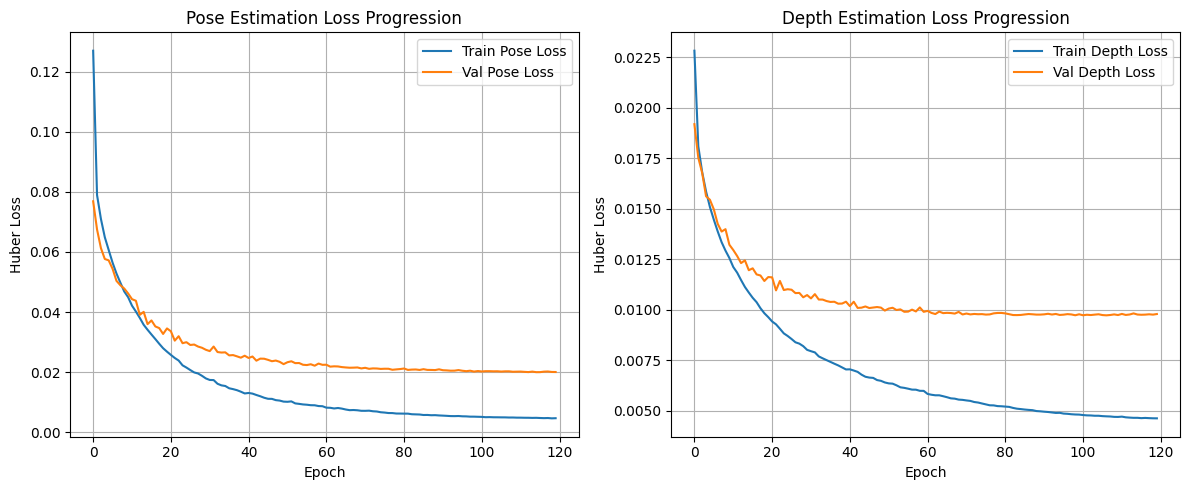

In [ ]:
# @title V3

import os
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
MULTI_DATASET_PATH = "/content/drive/MyDrive/GCD/paired_dataset_multitask.h5"  # Adjust based on where you uploaded it
BATCH_SIZE = 64
EPOCHS = 120
LEARNING_RATE = 1e-3
ETA_MIN = 1e-4  # Slower decay: keeps learning rate from shrinking below 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VAL_RATIO = 0.20  # Ratio of frames reserved for validation
DEPTH_NORM_SCALE = 500.0  # Max depth scale in mm for [0, 1] normalization

# --- PYTORCH DATASET LOADER (RAM CACHED) ---
class CapacitanceHandPoseDepthDataset(Dataset):
    def __init__(self, h5_path, run_indices=None):
        self.h5_path = h5_path

        # Load data into memory (RAM) to bypass high latency of Google Drive file reads
        with h5py.File(self.h5_path, 'r') as f:
            run_ids = f['run_ids'][:]

            if run_indices is not None:
                # Mask corresponding to specified run IDs
                self.indices = np.where(np.isin(run_ids, run_indices))[0]
            else:
                self.indices = np.arange(len(run_ids))

            # Pre-load only the sliced datasets into RAM
            self.capacitance = f['capacitance'][self.indices]
            self.joints = f['joints'][self.indices]
            self.depth = f['depth'][self.indices]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Normalize depth map to [0, 1] range to balance gradient magnitudes with joints
        depth_norm = self.depth[idx] / DEPTH_NORM_SCALE

        return (torch.tensor(self.capacitance[idx], dtype=torch.float32),
                torch.tensor(self.joints[idx].flatten(), dtype=torch.float32),
                torch.tensor(depth_norm, dtype=torch.float32))

# --- COORDCONV2D MODULE ---
class CoordConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CoordConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels + 2, out_channels, **kwargs)

    def forward(self, x):
        batch_size, _, h, w = x.size()

        # Generate X and Y normalized coordinate grids
        xx = torch.arange(w, device=x.device, dtype=x.dtype).view(1, 1, 1, w).expand(batch_size, 1, h, w)
        yy = torch.arange(h, device=x.device, dtype=x.dtype).view(1, 1, h, 1).expand(batch_size, 1, h, w)

        # Normalize to [-1, 1]
        xx = xx / (w - 1) * 2 - 1
        yy = yy / (h - 1) * 2 - 1

        # Concatenate grids to the input channels
        x_coords = torch.cat([x, xx, yy], dim=1)
        return self.conv(x_coords)

# --- RESIDUAL CNN BLOCK ---
class ResBlock(nn.Module):
    def __init__(self, channels):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return self.relu(out)

# --- MULTI-TASK NETWORK ARCHITECTURE ---
class CapacitanceHandPoseDepthNet(nn.Module):
    def __init__(self):
        super(CapacitanceHandPoseDepthNet, self).__init__()

        # --- Shared Convolutional Encoder ---
        self.coord_conv = CoordConv2d(2, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU()
        self.res1 = ResBlock(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # 14x8 -> 7x4

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.ReLU()
        self.res2 = ResBlock(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # 7x4 -> 3x2

        # Shared bottleneck size: 128 * 3 * 2 = 768

        # --- Head 1: Pose Regression Head ---
        self.fc1 = nn.Linear(768, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.relu_fc1 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        self.fc2 = nn.Linear(256, 128)
        self.relu_fc2 = nn.ReLU()
        self.fc_pose_out = nn.Linear(128, 63)

        # --- Head 2: Depth Reconstruction Decoder Head ---
        # Project 768 flat features to 64 channels of 6x9 resolution
        self.depth_fc = nn.Linear(768, 64 * 6 * 9)
        self.depth_bn_fc = nn.BatchNorm1d(64 * 6 * 9)
        self.depth_relu_fc = nn.ReLU()

        # Upsampling levels: 6x9 -> 12x18 -> 24x36 -> 48x72
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec1 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.bn_dec1 = nn.BatchNorm2d(32)
        self.relu_dec1 = nn.ReLU()

        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.bn_dec2 = nn.BatchNorm2d(16)
        self.relu_dec2 = nn.ReLU()

        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.bn_dec3 = nn.BatchNorm2d(8)
        self.relu_dec3 = nn.ReLU()

        self.dec_out = nn.Conv2d(8, 1, kernel_size=3, padding=1)
        self.relu_out = nn.ReLU() # Depth maps are strictly non-negative

    def forward(self, x):
        # Encoder
        x = self.relu1(self.bn1(self.coord_conv(x)))
        x = self.pool1(self.res1(x))
        x = self.pool2(self.res2(self.relu2(self.bn2(self.conv2(x)))))

        feat = x.view(x.size(0), -1)

        # Pose prediction
        pose = self.dropout(self.relu_fc1(self.bn_fc1(self.fc1(feat))))
        pose = self.relu_fc2(self.fc2(pose))
        pose = self.fc_pose_out(pose)

        # Depth reconstruction
        depth_feat = self.depth_relu_fc(self.depth_bn_fc(self.depth_fc(feat)))
        depth_feat = depth_feat.view(-1, 64, 6, 9)

        d = self.relu_dec1(self.bn_dec1(self.dec1(self.up1(depth_feat))))
        d = self.relu_dec2(self.bn_dec2(self.dec2(self.up2(d))))
        d = self.relu_dec3(self.bn_dec3(self.dec3(self.up3(d))))
        depth = self.relu_out(self.dec_out(d))

        return pose, depth

def main():
    if not os.path.exists(MULTI_DATASET_PATH):
        print(f"Error: Dataset not found at {MULTI_DATASET_PATH}.")
        print("Please check DATASET_PATH config or upload paired_dataset_multitask.h5 to Google Colab.")
        return

    # --- RANDOM SPLIT BY FRAMES ---
    full_dataset = CapacitanceHandPoseDepthDataset(MULTI_DATASET_PATH)
    total_samples = len(full_dataset)
    val_size = int(total_samples * VAL_RATIO)
    train_size = total_samples - val_size

    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Total samples: {total_samples}")
    print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

    # --- MODEL & TRAINING PARAMETERS ---
    model = CapacitanceHandPoseDepthNet().to(DEVICE)
    criterion_pose = nn.SmoothL1Loss()  # Huber Loss for coordinates
    criterion_depth = nn.SmoothL1Loss()  # Huber Loss for depth maps

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Cosine Annealing learning rate schedule with slower decay (eta_min)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=ETA_MIN)

    train_losses = []
    val_losses = []
    train_pose_losses = []
    val_pose_losses = []
    train_depth_losses = []
    val_depth_losses = []

    best_val_loss = float('inf')

    print(f"\nTraining multi-task model on device: {DEVICE}...")

    for epoch in range(EPOCHS):
        model.train()
        epoch_train_loss = 0.0
        epoch_train_pose_loss = 0.0
        epoch_train_depth_loss = 0.0

        for cap_img, gt_joints, gt_depth in train_loader:
            cap_img, gt_joints, gt_depth = cap_img.to(DEVICE), gt_joints.to(DEVICE), gt_depth.to(DEVICE)

            optimizer.zero_grad()
            pred_pose, pred_depth = model(cap_img)

            loss_pose = criterion_pose(pred_pose, gt_joints)
            loss_depth = criterion_depth(pred_depth, gt_depth)

            # Combine losses (1:1 weight works well since depth is scaled to [0, 1])
            loss = loss_pose + loss_depth

            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * cap_img.size(0)
            epoch_train_pose_loss += loss_pose.item() * cap_img.size(0)
            epoch_train_depth_loss += loss_depth.item() * cap_img.size(0)

        epoch_train_loss /= len(train_dataset)
        epoch_train_pose_loss /= len(train_dataset)
        epoch_train_depth_loss /= len(train_dataset)

        train_losses.append(epoch_train_loss)
        train_pose_losses.append(epoch_train_pose_loss)
        train_depth_losses.append(epoch_train_depth_loss)

        # Validation Phase
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_pose_loss = 0.0
        epoch_val_depth_loss = 0.0

        with torch.no_grad():
            for cap_img, gt_joints, gt_depth in val_loader:
                cap_img, gt_joints, gt_depth = cap_img.to(DEVICE), gt_joints.to(DEVICE), gt_depth.to(DEVICE)
                pred_pose, pred_depth = model(cap_img)

                loss_pose = criterion_pose(pred_pose, gt_joints)
                loss_depth = criterion_depth(pred_depth, gt_depth)
                loss = loss_pose + loss_depth

                epoch_val_loss += loss.item() * cap_img.size(0)
                epoch_val_pose_loss += loss_pose.item() * cap_img.size(0)
                epoch_val_depth_loss += loss_depth.item() * cap_img.size(0)

        epoch_val_loss /= len(val_dataset)
        epoch_val_pose_loss /= len(val_dataset)
        epoch_val_depth_loss /= len(val_dataset)

        val_losses.append(epoch_val_loss)
        val_pose_losses.append(epoch_val_pose_loss)
        val_depth_losses.append(epoch_val_depth_loss)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        # Print progress (every 5 epochs, and the first/last epochs)
        if (epoch + 1) % 5 == 0 or epoch == 0 or (epoch + 1) == EPOCHS:
            print(f"Epoch [{epoch+1:3d}/{EPOCHS:3d}] | LR: {current_lr:.6e} | Total Val Loss: {epoch_val_loss:.6f} (Pose: {epoch_val_pose_loss:.6f}, Depth: {epoch_val_depth_loss:.6f})")

        # Save best model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), "best_model_v3.pth")

    print(f"\nTraining completed! Best Validation Loss: {best_val_loss:.6f}")

    # --- EVALUATION AND RESULTS ---
    # Load best weights
    model.load_state_dict(torch.load("best_model_v3.pth"))
    model.eval()

    # Calculate average joint error in normalized space and physical mm, and depth error in mm
    total_joint_err = 0.0
    total_depth_err_mm = 0.0

    with torch.no_grad():
        for cap_img, gt_joints, gt_depth in val_loader:
            cap_img, gt_joints, gt_depth = cap_img.to(DEVICE), gt_joints.to(DEVICE), gt_depth.to(DEVICE)
            pred_pose, pred_depth = model(cap_img)

            # Reshape output to (Batch, 21, 3)
            pred_j = pred_pose.view(-1, 21, 3)
            gt_j = gt_joints.view(-1, 21, 3)

            # Distance error per joint
            dist = torch.sqrt(torch.sum((pred_j - gt_j)**2, dim=2)) # (Batch, 21)
            total_joint_err += torch.mean(dist).item() * cap_img.size(0)

            # Mean absolute depth error rescaled to mm
            depth_err = torch.abs(pred_depth - gt_depth) * DEPTH_NORM_SCALE
            total_depth_err_mm += torch.mean(depth_err).item() * cap_img.size(0)

    avg_joint_err_units = total_joint_err / len(val_dataset)
    avg_joint_err_mm = avg_joint_err_units * 36.0878
    avg_depth_err_mm = total_depth_err_mm / len(val_dataset)

    print(f"\nAverage Estimation Error on Validation Set:")
    print(f" -> Pose:  {avg_joint_err_units:.4f} units ({avg_joint_err_mm:.2f} mm)")
    print(f" -> Depth: {avg_depth_err_mm:.2f} mm")

    # --- PLOT LOSSES ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_pose_losses, label="Train Pose Loss")
    plt.plot(val_pose_losses, label="Val Pose Loss")
    plt.title("Pose Estimation Loss Progression")
    plt.xlabel("Epoch")
    plt.ylabel("Huber Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(train_depth_losses, label="Train Depth Loss")
    plt.plot(val_depth_losses, label="Val Depth Loss")
    plt.title("Depth Estimation Loss Progression")
    plt.xlabel("Epoch")
    plt.ylabel("Huber Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("loss_progression_v3.png")
    print("\nSaved training loss progression plots to loss_progression_v3.png")

if __name__ == '__main__':
    main()